In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('All libraries imported successfully!')

All libraries imported successfully!


In [4]:
from google.colab import files
uploaded = files.upload()

Saving house-prices-advanced-regression-techniques (1).zip to house-prices-advanced-regression-techniques (1).zip


In [5]:
import zipfile

with zipfile.ZipFile('house-prices-advanced-regression-techniques (1).zip', 'r') as z:
    z.extractall('house_data')

df = pd.read_csv('house_data/train.csv')

print('Shape:', df.shape)
print(df.head())

Shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0  

In [7]:
# Select features and target
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath']
target = 'SalePrice'

df_model = df[features + [target]].dropna()

print('Dataset ready. Rows:', len(df_model))
print(df_model.describe())

Dataset ready. Rows: 1460
         GrLivArea  BedroomAbvGr     FullBath      SalePrice
count  1460.000000   1460.000000  1460.000000    1460.000000
mean   1515.463699      2.866438     1.565068  180921.195890
std     525.480383      0.815778     0.550916   79442.502883
min     334.000000      0.000000     0.000000   34900.000000
25%    1129.500000      2.000000     1.000000  129975.000000
50%    1464.000000      3.000000     2.000000  163000.000000
75%    1776.750000      3.000000     2.000000  214000.000000
max    5642.000000      8.000000     3.000000  755000.000000


In [8]:
# Split into train and test sets
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 1168
Testing samples: 292


In [9]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully!')
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)

Model trained successfully!
Coefficients: [   104.02630701 -26655.16535734  30014.32410896]
Intercept: 52261.74862694461


In [10]:
# Evaluate the model
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE  (Mean Absolute Error): ${mae:,.0f}')
print(f'RMSE (Root Mean Sq Error):  ${rmse:,.0f}')
print(f'R2 Score (Accuracy):         {r2:.4f} ({r2*100:.1f}%)')

MAE  (Mean Absolute Error): $35,788
RMSE (Root Mean Sq Error):  $52,976
R2 Score (Accuracy):         0.6341 (63.4%)


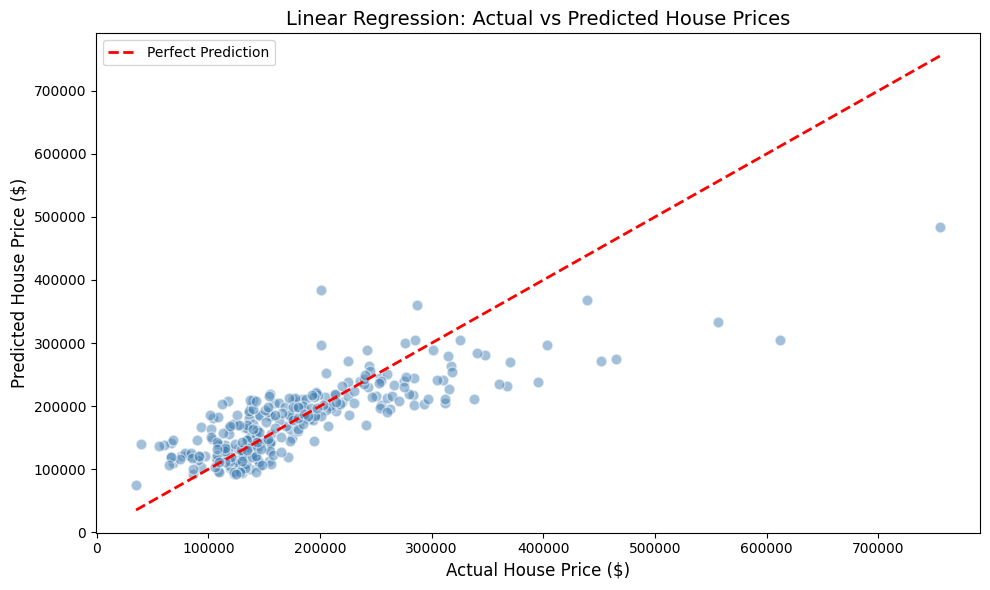

Plot saved!


In [11]:
# Plot Actual vs Predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual House Price ($)', fontsize=12)
plt.ylabel('Predicted House Price ($)', fontsize=12)
plt.title('Linear Regression: Actual vs Predicted House Prices', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('house_price_prediction.png', dpi=150)
plt.show()
print('Plot saved!')

In [12]:
import os
files_list = os.listdir('/content')
print(files_list)

['.config', 'house_price_prediction.png', 'house-prices-advanced-regression-techniques (1).zip', 'house_data', 'sample_data']


In [13]:
from google.colab import files
files.download('house_price_prediction.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>